In [21]:
# ════════════════════════════════════════════════════════════════
# PART 0 — Imports & Device
# ════════════════════════════════════════════════════════════════
import re, unicodedata, warnings, pickle
from collections import Counter
 
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
 
from embed_utils import embed_batch, embed_combined
from sklearn.model_selection import train_test_split
from sklearn.neighbors       import NearestNeighbors
from sklearn.metrics         import (accuracy_score, precision_score,
                                     recall_score, f1_score,
                                     classification_report, confusion_matrix)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model            import LogisticRegression
from sklearn.ensemble                import RandomForestClassifier
 
from transformers          import AutoTokenizer, AutoModel
from torch_geometric.data  import Data

 
from pythainlp.tokenize import word_tokenize
from pythainlp.corpus   import thai_stopwords
 
warnings.filterwarnings("ignore", message=".*encoder_attention_mask.*")
warnings.filterwarnings("ignore", message=".*CamembertSdpaSelfAttention.*")
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
 
try:
    plt.rcParams['font.family'] = 'Tahoma'
except Exception:
    pass

Using device: cuda


In [22]:
# ════════════════════════════════════════════════════════════════
# PART 1 — Load & Clean Data
# ════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("PART 1 | Load & Clean Data")
print("="*70)
 
ZW = ''.join(['\u200B', '\u200C', '\u200D', '\uFEFF'])
 
def normalize_thai(s):
    if pd.isna(s):
        return None
    s = str(s).replace('\u00A0', ' ').translate({ord(ch): None for ch in ZW})
    s = unicodedata.normalize('NFC', s)
    s = re.sub(r'\s+', ' ', s).strip()
    s = re.sub(r'([\u0E31\u0E34-\u0E3A\u0E47-\u0E4E])\1+', r'\1', s)
    return s
 
df = pd.read_csv('AFNC_news_dataset_tf-2.csv')
df.columns = df.columns.str.strip()
 
df['ประเภทข่าว']     = df['ประเภทข่าว'].astype(str).str.strip().apply(normalize_thai)
df['หมวดหมู่ของข่าว'] = df['หมวดหมู่ของข่าว'].astype(str).str.strip().apply(normalize_thai)
 
# กรองค่าไม่สมบูรณ์
df = df[~df['ประเภทข่าว'].isin([None, 'nan', 'NaN', '', 'None'])]
df = df[~df['หมวดหมู่ของข่าว'].isin([None, 'nan', 'NaN', '', 'None'])]
df = df.dropna(subset=['หัวข้อข่าว', 'ประเภทข่าว', 'หมวดหมู่ของข่าว']).reset_index(drop=True)
 
# Label mapping  (ข่าวจริง=0, ข่าวปลอม=1)
label2id = {'ข่าวจริง': 0, 'ข่าวปลอม': 1}
id2label = {0: 'ข่าวจริง', 1: 'ข่าวปลอม'}
 
df['label_id'] = df['ประเภทข่าว'].map(label2id)
df = df.dropna(subset=['label_id']).reset_index(drop=True)
df['label_id'] = df['label_id'].astype(int)
 
# Category mapping
cats   = sorted(df['หมวดหมู่ของข่าว'].unique())
cat2id = {c: i for i, c in enumerate(cats)}
id2cat = {i: c for c, i in cat2id.items()}
df['category_id'] = df['หมวดหมู่ของข่าว'].map(cat2id)
 
print(f"Dataset  : {len(df):,} rows")
print(f"Labels   : {label2id}")
print(f"Categories ({len(cats)}): {cats[:5]} ...")


PART 1 | Load & Clean Data
Dataset  : 11,109 rows
Labels   : {'ข่าวจริง': 0, 'ข่าวปลอม': 1}
Categories (8): ['การเงิน-หุ้น', 'ข่าวอื่นๆ', 'ความสงบและความมั่นคง', 'นโยบายรัฐบาล-ข่าวสาร', 'ผลิตภัณฑ์สุขภาพ'] ...


In [23]:
# ════════════════════════════════════════════════════════════════
# PART 2 — WangchanBERT Embeddings
# ════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("PART 2 | WangchanBERT Embeddings")
print("="*70)
 
WCB_NAME  = "airesearch/wangchanberta-base-att-spm-uncased"
tokenizer = AutoTokenizer.from_pretrained(WCB_NAME, use_fast=False)
lm_model  = AutoModel.from_pretrained(WCB_NAME).to(device).eval()
 
texts_all = df['หัวข้อข่าว'].fillna("").astype(str).tolist()  

print("Creating WangchanBERT embeddings ...")
content_emb = embed_batch(texts_all, tokenizer, lm_model, device)
print(f"Embedding shape: {content_emb.shape}")

x_all     = content_emb     # embed_batch L2-normalize ให้แล้ว
y_all     = df['label_id'].values
y_all    = df['label_id'].values
y_cat_all = df['category_id'].values
 


PART 2 | WangchanBERT Embeddings


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3483.21it/s]
CamembertModel LOAD REPORT from: airesearch/wangchanberta-base-att-spm-uncased
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Creating WangchanBERT embeddings ...
Embedding shape: (11109, 768)



PART 3 | Balance Dataset
Balanced: 5744  (จริง: 2872, ปลอม: 2872)


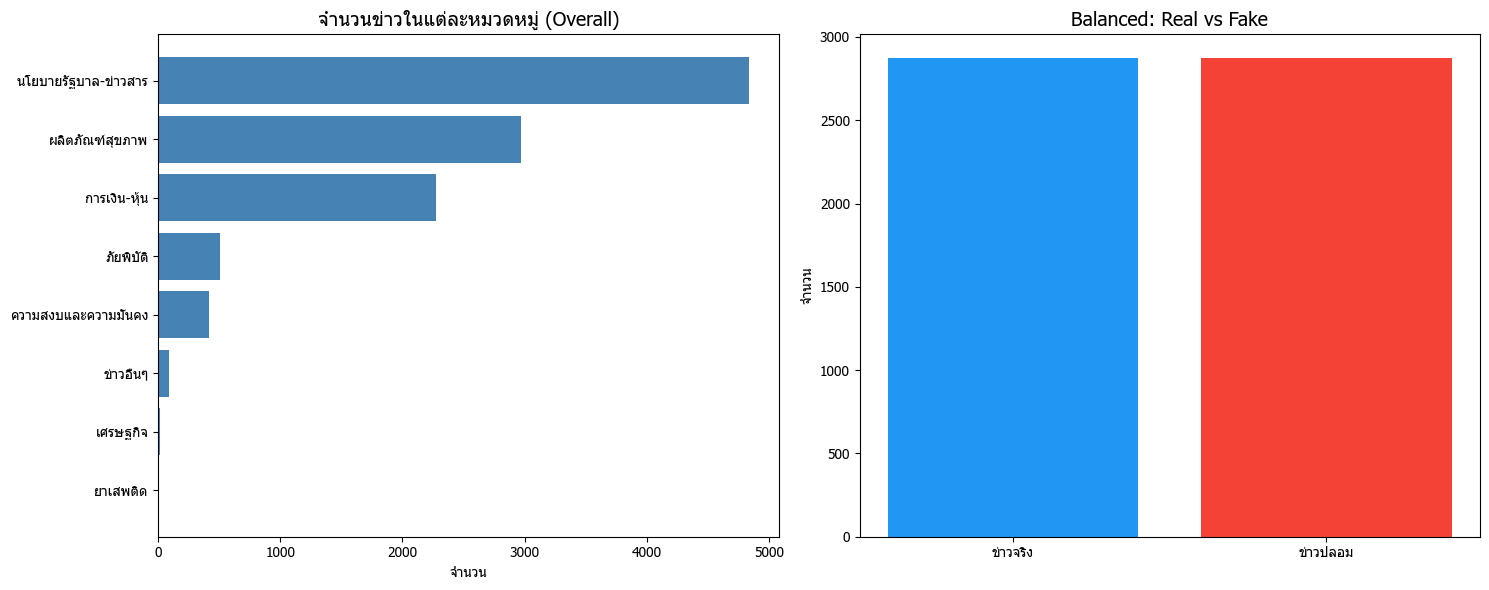

In [24]:
# ════════════════════════════════════════════════════════════════
# PART 3 — Balance Dataset + Visualisation
# ════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("PART 3 | Balance Dataset")
print("="*70)
 
df_true = df[df['label_id'] == 0]
df_fake = df[df['label_id'] == 1]
min_len = min(len(df_true), len(df_fake))
 
# ✅ ใหม่ — เลือกข่าวล่าสุด (เหมือนไฟล์ 1)
DATE_COL = 'วันและเวลาที่เผยแพร่'

def convert_thai_date(date_str):
    if pd.isna(date_str): return pd.NaT
    s = str(date_str).strip()
    if s == 'NaT': return pd.NaT
    if ' ' in s: s = s.split(' ')[0]
    if '/' in s:
        parts = s.split('/')
        fixed = [str(int(p)-543) if (p.isdigit() and len(p)==4 and int(p)>2400)
                 else p for p in parts]
        return "-".join(fixed)
    return s

if DATE_COL in df.columns:
    df['parsed_date'] = pd.to_datetime(
        df[DATE_COL].apply(convert_thai_date), dayfirst=True, errors='coerce'
    )
    use_date = df['parsed_date'].notna().sum() > 0
else:
    use_date = False

idx_real = np.where(y_all == 0)[0]
idx_fake = np.where(y_all == 1)[0]
min_len  = min(len(idx_real), len(idx_fake))

def _pick_balanced(indices, sort_col, n):
    if sort_col:
        rows = df.iloc[indices].sort_values(by=sort_col, ascending=False)
        return rows.head(n).index.to_numpy()
    return indices[:n]

sort_col       = 'parsed_date' if use_date else None
idx_real_b     = _pick_balanced(idx_real, sort_col, min_len)
idx_fake_b     = _pick_balanced(idx_fake, sort_col, min_len)
bal_orig_idx   = np.concatenate([idx_real_b, idx_fake_b])

x_balanced     = x_all[bal_orig_idx]
y_balanced     = y_all[bal_orig_idx]
y_cat_balanced = y_cat_all[bal_orig_idx]
texts_balanced = [texts_all[i] for i in bal_orig_idx]
N_balanced     = len(x_balanced)

print(f"Balanced: {N_balanced}  (จริง: {min_len}, ปลอม: {min_len})")
 
# ── กราฟ Distribution ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
 
# กราฟ 1: Overall category (ข้อมูลทั้งหมด)
cat_cnt = df['หมวดหมู่ของข่าว'].value_counts()
axes[0].barh(cat_cnt.index[::-1], cat_cnt.values[::-1], color='steelblue')
axes[0].set_title('จำนวนข่าวในแต่ละหมวดหมู่ (Overall)', fontsize=14)
axes[0].set_xlabel('จำนวน')
 
# กราฟ 2: Real vs Fake (balanced)
bal_series = pd.Series(y_balanced).map(id2label)
bal_cnt    = bal_series.value_counts()
axes[1].bar(bal_cnt.index, bal_cnt.values, color=['#2196F3', '#F44336'])
axes[1].set_title('Balanced: Real vs Fake', fontsize=14)
axes[1].set_ylabel('จำนวน')
 
plt.tight_layout()
plt.savefig('img/graph_distribution.png', dpi=150)
plt.show()
 

In [25]:
# ════════════════════════════════════════════════════════════════
# PART 4 — Build kNN Graph + Split
# ════════════════════════════════════════════════════════════════
K = 10

# ── สร้าง kNN Graph ─────────────────────────────────────────
from torch_geometric.utils import coalesce

nbrs_full = NearestNeighbors(n_neighbors=K + 1, metric='cosine').fit(x_balanced)
dists_knn, indices_knn = nbrs_full.kneighbors(x_balanced)

src = np.repeat(np.arange(N_balanced), K)
dst = indices_knn[:, 1:].reshape(-1)
w   = 1.0 - dists_knn[:, 1:].reshape(-1)

edge_index_np  = np.vstack([src, dst])
edge_index_np  = np.concatenate([edge_index_np, edge_index_np[::-1, :]], axis=1)
edge_weight_np = np.concatenate([w, w])

edge_index  = torch.tensor(edge_index_np, dtype=torch.long)
edge_weight = torch.tensor(edge_weight_np, dtype=torch.float)

try:
    edge_index, edge_weight = coalesce(
        edge_index, edge_weight, N_balanced, reduce='mean'
    )
except Exception as e:
    print(f"coalesce warning: {e}")

print(f"Graph: {N_balanced} nodes | {edge_index.shape[1]:,} edges (k={K})")

# ── Split ────────────────────────────────────────────────────
idx_all = np.arange(N_balanced)
idx_train, idx_temp = train_test_split(idx_all, test_size=0.30,
                                        stratify=y_balanced, random_state=42)
idx_val, idx_test   = train_test_split(idx_temp, test_size=0.50,
                                        stratify=y_balanced[idx_temp], random_state=42)

train_mask = torch.zeros(N_balanced, dtype=torch.bool)
val_mask   = torch.zeros(N_balanced, dtype=torch.bool)
test_mask  = torch.zeros(N_balanced, dtype=torch.bool)
train_mask[idx_train] = True
val_mask[idx_val]     = True
test_mask[idx_test]   = True

# ── PyG Data (transductive) ──────────────────────────────────
data_gcn = Data(
    x          = torch.tensor(x_balanced, dtype=torch.float),
    y          = torch.tensor(y_balanced, dtype=torch.long),
    edge_index = edge_index,
    edge_attr  = edge_weight,
    train_mask = train_mask,
    val_mask   = val_mask,
    test_mask  = test_mask,
).to(device)

# ── numpy splits (inductive) ─────────────────────────────────
x_train, y_train = x_balanced[idx_train], y_balanced[idx_train]
x_val,   y_val   = x_balanced[idx_val],   y_balanced[idx_val]
x_test,  y_test  = x_balanced[idx_test],  y_balanced[idx_test]
y_cat_train      = y_cat_balanced[idx_train]
texts_train      = [texts_balanced[i] for i in idx_train]
texts_val        = [texts_balanced[i] for i in idx_val]
texts_test       = [texts_balanced[i] for i in idx_test]

print(f"Split → Train:{train_mask.sum()} | Val:{val_mask.sum()} | Test:{test_mask.sum()}")

Graph: 5744 nodes | 91,867 edges (k=10)
Split → Train:4020 | Val:862 | Test:862



PART 5 | GCN Model + Training


c:\Users\tt_pe\Documents\GitHub\Project_Thaifakenews\venv-gpu\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


 Epoch |     Loss |    Train |      Val | LR
-------------------------------------------------------
     1 |   0.3979 |   0.8102 |   0.8260 | 1.0e-03
    10 |   0.2696 |   0.8756 |   0.8573 | 1.0e-03
    20 |   0.2611 |   0.8803 |   0.8503 | 1.0e-03
    30 |   0.2519 |   0.8794 |   0.8561 | 1.0e-03
    40 |   0.2509 |   0.8876 |   0.8561 | 1.0e-03
    50 |   0.2389 |   0.8888 |   0.8515 | 1.0e-03
    60 |   0.2355 |   0.8910 |   0.8724 | 1.0e-03
    70 |   0.2214 |   0.8978 |   0.8712 | 5.0e-04
    80 |   0.2165 |   0.9000 |   0.8712 | 2.5e-04
    90 |   0.2155 |   0.9005 |   0.8701 | 2.5e-04
   100 |   0.2084 |   0.9062 |   0.8735 | 1.3e-04

Best Val Acc: 0.8759


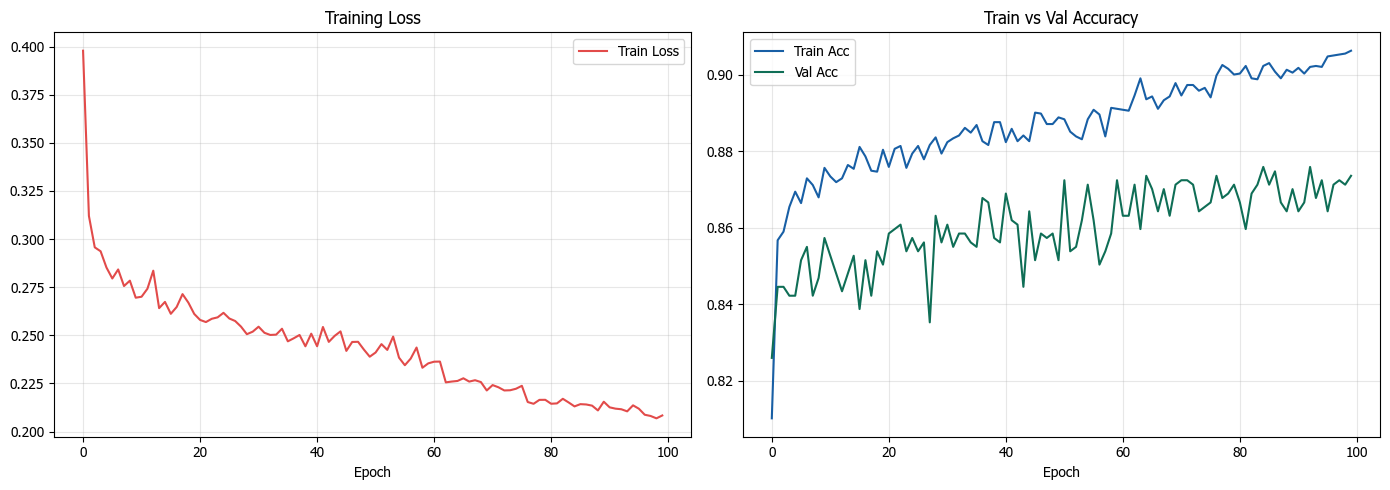

In [27]:
# ════════════════════════════════════════════════════════════════
# PART 5 — GCN Model + Training
# ════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("PART 5 | GCN Model + Training")
print("="*70)

from model_def   import GCNNet
from train_utils import train_epoch_inductive, eval_epoch_inductive

# ── Initialise ───────────────────────────────────────────────
# ✅ แก้ 1: ลบ model_gnn รอบแรกออก เหลือรอบเดียวที่มี args ครบ
model_gnn = GCNNet(in_channels=768, hidden_channels=256,
                   out_channels=2, dropout_rate=0.4).to(device)

optimizer = torch.optim.Adam(model_gnn.parameters(), lr=1e-3, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=10, factor=0.5, verbose=True
)

class_counts  = np.bincount(y_train)
class_weights = torch.tensor(1.0 / class_counts, dtype=torch.float, device=device)
class_weights /= class_weights.sum()
criterion = nn.CrossEntropyLoss(weight=class_weights)

# ✅ แก้ 2: support_nbrs define ครั้งเดียว (ลบรอบแรกออก)
support_nbrs = NearestNeighbors(
    n_neighbors=K + 1, metric='cosine', algorithm='brute'
).fit(x_train)

# ── Training Loop ────────────────────────────────────────────
# ✅ แก้ 3: ใช้ train_epoch_inductive / eval_epoch_inductive จาก train_utils
#           ลบ train_epoch และ eval_epoch ที่ define เองออกทั้งหมด
EPOCHS, BATCH_SIZE, PATIENCE = 100, 32, 20
history      = {'train_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0
patience_cnt = 0

print(f"{'Epoch':>6} | {'Loss':>8} | {'Train':>8} | {'Val':>8} | LR")
print("-" * 55)

for epoch in range(1, EPOCHS + 1):
    # ✅ แก้ 4: เปลี่ยนจาก train_epoch → train_epoch_inductive
    tr_loss, tr_acc = train_epoch_inductive(
        model        = model_gnn,
        optimizer    = optimizer,
        criterion    = criterion,
        x_query      = x_train,
        y_query      = y_train,
        x_support    = x_train,
        support_nbrs = support_nbrs,
        k            = K,
        device       = device,
        batch_size   = BATCH_SIZE,
    )
    val_acc, _, _ = eval_epoch_inductive(
        model        = model_gnn,
        x_query      = x_val,
        y_query      = y_val,
        x_support    = x_train,
        support_nbrs = support_nbrs,
        k            = K,
        device       = device,
    )

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(val_acc)

    scheduler.step(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc; patience_cnt = 0
        torch.save(model_gnn.state_dict(), 'best_model.pth')
    else:
        patience_cnt += 1

    if epoch % 10 == 0 or epoch == 1:
        lr = optimizer.param_groups[0]['lr']
        print(f"{epoch:>6} | {tr_loss:>8.4f} | {tr_acc:>8.4f} | {val_acc:>8.4f} | {lr:.1e}")

    if patience_cnt >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}")
        break

print(f"\nBest Val Acc: {best_val_acc:.4f}")

# ── Plot training ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history['train_loss'], color='#E24B4A', label='Train Loss')
axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history['train_acc'], color='#185FA5', label='Train Acc')
axes[1].plot(history['val_acc'],   color='#0F6E56', label='Val Acc')
axes[1].set_title('Train vs Val Accuracy'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('img/graph_training_curves.png', dpi=150)
plt.show()

In [28]:
# ════════════════════════════════════════════════════════════════
# PART 6 — Evaluate GCN (Transductive Test-Mask)
# ════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("PART 6 | GCN Evaluation on Test Set")
print("="*70)
 
sd = torch.load('best_model.pth', map_location=device)

# เก็บแค่ key ที่ GCNNet ต้องการ
gcn_keys = set(model_gnn.state_dict().keys())
sd_filtered = {k: v for k, v in sd.items() if k in gcn_keys}

model_gnn.load_state_dict(sd_filtered, strict=True)
print(f"โหลด {len(sd_filtered)} keys จากทั้งหมด {len(sd)} keys")
model_gnn.eval()
 


test_acc, y_true_gcn, y_pred_gcn = eval_epoch_inductive(
    model        = model_gnn,
    x_query      = x_test,
    y_query      = y_test,
    x_support    = x_train,
    support_nbrs = support_nbrs,
    k            = K,
    device       = device,
)
 
acc_gcn  = accuracy_score(y_true_gcn, y_pred_gcn)
prec_gcn = precision_score(y_true_gcn, y_pred_gcn, average='weighted', zero_division=0)
rec_gcn  = recall_score(y_true_gcn, y_pred_gcn, average='weighted', zero_division=0)
f1_gcn   = f1_score(y_true_gcn, y_pred_gcn, average='weighted', zero_division=0)
 
results_gcn = {
    "Accuracy":           float(acc_gcn),
    "Precision_weighted": float(prec_gcn),
    "Recall_weighted":    float(rec_gcn),
    "F1_weighted":        float(f1_gcn),
}
 
print(f"Accuracy : {acc_gcn:.4f}")
print(f"Precision: {prec_gcn:.4f}")
print(f"Recall   : {rec_gcn:.4f}")
print(f"F1-score : {f1_gcn:.4f}")
print("\n", classification_report(y_true_gcn, y_pred_gcn,
       target_names=[id2label[0], id2label[1]], digits=4))


PART 6 | GCN Evaluation on Test Set
โหลด 4 keys จากทั้งหมด 4 keys


C:\Users\tt_pe\AppData\Local\Temp\ipykernel_23056\815831074.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load('best_model.pth', map_location=device)


Accuracy : 0.8712
Precision: 0.8723
Recall   : 0.8712
F1-score : 0.8711

               precision    recall  f1-score   support

    ข่าวจริง     0.8922    0.8445    0.8677       431
    ข่าวปลอม     0.8524    0.8979    0.8746       431

    accuracy                         0.8712       862
   macro avg     0.8723    0.8712    0.8711       862
weighted avg     0.8723    0.8712    0.8711       862



In [29]:
# ════════════════════════════════════════════════════════════════
# PART 7 — Predict New Samples (Inductive)
# ════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("PART 7 | Predict New Samples (Inductive Star-Graph)")
print("="*70)
 
# inference kNN ใช้ข้อมูล Balanced ทั้งหมด
infer_nbrs = NearestNeighbors(n_neighbors=K, metric='cosine').fit(x_balanced)
 
def predict_news(content: str, topn: int = K) -> dict:
    emb_raw = get_bert_embeddings_batch([content])[0]
    emb     = normalize(emb_raw.reshape(1, -1), norm='l2')[0]
 
    dists, idxs = infer_nbrs.kneighbors(emb.reshape(1, -1), n_neighbors=topn)
    idxs, dists = idxs[0], dists[0]
 
    neighbor_cats = [id2cat[c] for c in y_cat_balanced[idxs]]
    pred_category = Counter(neighbor_cats).most_common(1)[0][0]
 
    x_n  = np.vstack([emb, x_balanced[idxs]])
    nb   = np.arange(1, topn + 1)
    src  = np.concatenate([np.zeros(topn, int), nb])
    dst  = np.concatenate([nb, np.zeros(topn, int)])
    ew   = np.concatenate([1 - dists, 1 - dists])
 
    g = Data(
        x          = torch.tensor(x_n,              dtype=torch.float, device=device),
        edge_index = torch.tensor(np.stack([src,dst]), dtype=torch.long, device=device),
        edge_attr  = torch.tensor(ew,               dtype=torch.float, device=device),
    )
    model_gnn.eval()
    with torch.no_grad():
        probas  = torch.softmax(model_gnn(g), dim=1)[0].cpu().numpy()
    pred_id = int(np.argmax(probas))
    return {
        'label': id2label[pred_id], 'probability': float(probas[pred_id]),
        'proba_all': probas.tolist(), 'category': pred_category,
        'neighbor_cats': neighbor_cats, 'pred_id': pred_id,
    }
 
test_news_data = [
    # ข่าวจริง (label=0)
    {"content": "ททท. เปิดตัว 'ลิซ่า' เป็นตัวแทนการท่องเที่ยวไทย Amazing Thailand Ambassador", "label_true": 0},
    {"content": "สั่งสำรวจ-เก็บวัตถุโบราณ เร่งบูรณะ 'พระธาตุโนนตาล' หลังพังถล่มจากฝนตกหนัก", "label_true": 0},
    {"content": "บขส. เปิดให้บริการเดินรถโดยสาร เส้นทาง ขอนแก่น – นครหลวงเวียงจันทน์",       "label_true": 0},
    {"content": "อุทยานฯ เขาพนมเบญจา ชวนนักท่องเที่ยว ตามรอยจูราสสิค เวิลด์",               "label_true": 0},
    {"content": "พบอิฐโบราณชิ้นสำคัญ หลักฐานทางประวัติศาสตร์ที่เก่าแก่ของเชียงราย",          "label_true": 0},
    {"content": "อาการเจ็บหน้าอก สัญญาณอันตรายที่ไม่ควรมองข้าม",                            "label_true": 0},
    {"content": "กกล.บูรพา จับกุมแรงงานกัมพูชา 11 คน ลักลอบข้ามชายแดนสระแก้ว",              "label_true": 0},
    {"content": "ททท.คาด 'เทศกาลกินผักภูเก็ต 2568' รายได้ทะลุ 22,000 ล้านบาท",               "label_true": 0},
    # ข่าวปลอม (label=1)
    {"content": "ด่วน! สะพานกรุงเทพถล่ม มีผู้เสียชีวิต 36 ราย",                             "label_true": 1},
    {"content": "การดื่มน้ำมะนาวสามารถทำลายมะเร็งเนื้อร้ายที่รุนแรงได้",                     "label_true": 1},
    {"content": "ผู้สูงอายุ 60 ปีขึ้นไป รับเงินอุดหนุนพิเศษ 3,000 บาท ไม่ต้องลงทะเบียน",   "label_true": 1},
    {"content": "กรมการขนส่งเปิดทำใบขับขี่ออนไลน์ ผ่านเพจเฟซบุ๊ก Pages DTL Noline",         "label_true": 1},
    {"content": "กินถั่วลิสงวันละ 1 กำมือ ช่วยรักษาอาการวัยทอง อารมณ์แปรปรวน",             "label_true": 1},
    {"content": "กฟภ. เปิดช่องทางติดต่อด่วน ทางไลน์ไอดี 'pea9394'",                         "label_true": 1},
    {"content": "สินเชื่อด่วนออมสิน สมัครง่าย ไม่ต้องใช้เอกสาร",                             "label_true": 1},
    {"content": "วางก้อนน้ำแข็งบนท้ายทอย ช่วยรักษาโรคหลอดเลือดหัวใจ",                       "label_true": 1},
]
 
y_true_p7, y_pred_p7 = [], []
print(f"\n{'':>3} {'TRUE':<12} {'PRED':<12} {'CONF':>6}  HEADLINE")
print("-" * 70)
for i, news in enumerate(test_news_data):
    try:
        res = predict_news(news['content'])
        y_true_p7.append(news['label_true'])
        y_pred_p7.append(res['pred_id'])
        ok = "✅" if res['pred_id'] == news['label_true'] else "❌"
        print(f"{ok} {id2label[news['label_true']]:<12} {res['label']:<12} "
              f"{res['probability']:>5.1%}  {news['content'][:45]}...")
    except Exception as e:
        print(f"[{i}] Error: {e}")
 
if y_pred_p7:
    print("\n", classification_report(
        y_true_p7, y_pred_p7,
        target_names=[id2label[0], id2label[1]], zero_division=0
    ))


PART 7 | Predict New Samples (Inductive Star-Graph)

    TRUE         PRED           CONF  HEADLINE
----------------------------------------------------------------------
[0] Error: name 'get_bert_embeddings_batch' is not defined
[1] Error: name 'get_bert_embeddings_batch' is not defined
[2] Error: name 'get_bert_embeddings_batch' is not defined
[3] Error: name 'get_bert_embeddings_batch' is not defined
[4] Error: name 'get_bert_embeddings_batch' is not defined
[5] Error: name 'get_bert_embeddings_batch' is not defined
[6] Error: name 'get_bert_embeddings_batch' is not defined
[7] Error: name 'get_bert_embeddings_batch' is not defined
[8] Error: name 'get_bert_embeddings_batch' is not defined
[9] Error: name 'get_bert_embeddings_batch' is not defined
[10] Error: name 'get_bert_embeddings_batch' is not defined
[11] Error: name 'get_bert_embeddings_batch' is not defined
[12] Error: name 'get_bert_embeddings_batch' is not defined
[13] Error: name 'get_bert_embeddings_batch' is not define

In [ ]:
# ════════════════════════════════════════════════════════════════
# PART 8 — Baseline Models
# ════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("PART 8 | Baseline Models")
print("="*70)
 
y_train_base = y_balanced[idx_train]
y_test_base  = y_balanced[idx_test]
train_texts  = [texts_balanced[i] for i in idx_train]
test_texts   = [texts_balanced[i] for i in idx_test]
 
results_comparison = {'1. WangchanBERT + kNN-GCN': results_gcn}
 
# ── Baseline 1: TF-IDF + Logistic Regression ────────────────
print("\nBaseline 1: TF-IDF + Logistic Regression ...")
 
def thai_tokenizer(text):
    return word_tokenize(str(text), engine='newmm', keep_whitespace=False)
 
tfidf         = TfidfVectorizer(tokenizer=thai_tokenizer, max_features=5000)
X_tr_tfidf    = tfidf.fit_transform(train_texts)
X_te_tfidf    = tfidf.transform(test_texts)
clf_lr        = LogisticRegression(max_iter=1000, random_state=42)
clf_lr.fit(X_tr_tfidf, y_train_base)
y_pred_tfidf  = clf_lr.predict(X_te_tfidf)
 
results_comparison['2. TF-IDF + LR'] = {
    "Accuracy":           accuracy_score(y_test_base, y_pred_tfidf),
    "Precision_weighted": precision_score(y_test_base, y_pred_tfidf, average='weighted', zero_division=0),
    "Recall_weighted":    recall_score(y_test_base, y_pred_tfidf, average='weighted', zero_division=0),
    "F1_weighted":        f1_score(y_test_base, y_pred_tfidf, average='weighted', zero_division=0),
}
print("Done ✅")
 
# ── Baseline 2: WangchanBERT + Random Forest ────────────────
print("\nBaseline 2: WangchanBERT Embedding + Random Forest ...")
 
clf_rf        = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_rf.fit(x_balanced[idx_train], y_train_base)
y_pred_rf     = clf_rf.predict(x_balanced[idx_test])
 
results_comparison['3. WangchanBERT + RF'] = {
    "Accuracy":           accuracy_score(y_test_base, y_pred_rf),
    "Precision_weighted": precision_score(y_test_base, y_pred_rf, average='weighted', zero_division=0),
    "Recall_weighted":    recall_score(y_test_base, y_pred_rf, average='weighted', zero_division=0),
    "F1_weighted":        f1_score(y_test_base, y_pred_rf, average='weighted', zero_division=0),
}
print("Done ✅")
 
# ── Baseline 3: XLM-RoBERTa + Logistic Regression ───────────
print("\nBaseline 3: XLM-RoBERTa + Logistic Regression ...")

XLM_NAME = "xlm-roberta-base"
tok_xlm  = AutoTokenizer.from_pretrained(XLM_NAME)
mdl_xlm  = AutoModel.from_pretrained(XLM_NAME).to(device).eval()

# ✅ แก้ 1: เปลี่ยนจาก get_bert_embeddings_batch → embed_batch
xlm_emb  = embed_batch(
    texts_balanced,
    tokenizer  = tok_xlm,
    bert_model = mdl_xlm,    # ✅ แก้ 2: parameter ชื่อ bert_model ไม่ใช่ model
    device     = device,
    max_length = 256,
    batch_size = 32,
)

 
clf_xlm = LogisticRegression(max_iter=1000, random_state=42)
clf_xlm.fit(xlm_emb[idx_train], y_train_base)    # ✅ ใช้ xlm_emb โดยตรง
y_pred_xlm = clf_xlm.predict(xlm_emb[idx_test])  # ✅ ใช้ xlm_emb โดยตรง
 
results_comparison['4. XLM-RoBERTa + LR'] = {
    "Accuracy":           accuracy_score(y_test_base, y_pred_xlm),
    "Precision_weighted": precision_score(y_test_base, y_pred_xlm, average='weighted', zero_division=0),
    "Recall_weighted":    recall_score(y_test_base, y_pred_xlm, average='weighted', zero_division=0),
    "F1_weighted":        f1_score(y_test_base, y_pred_xlm, average='weighted', zero_division=0),
}
print("Done ✅")


PART 8 | Baseline Models

Baseline 1: TF-IDF + Logistic Regression ...


c:\Users\tt_pe\Documents\GitHub\Project_Thaifakenews\venv-gpu\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Done ✅

Baseline 2: WangchanBERT Embedding + Random Forest ...
Done ✅

Baseline 3: XLM-RoBERTa + Logistic Regression ...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2706.14it/s]
XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


NameError: name 'get_bert_embeddings_batch' is not defined

In [ ]:
# ════════════════════════════════════════════════════════════════
# PART 9 — Comparison Table & Bar Chart
# ════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("PART 9 | Model Comparison Results")
print("="*70)
 
df_res = pd.DataFrame(results_comparison).T[
    ['Accuracy', 'Precision_weighted', 'Recall_weighted', 'F1_weighted']
]
print(df_res.round(4).to_string())
 
fig, ax = plt.subplots(figsize=(14, 7))
df_res.plot(kind='bar', ax=ax, colormap='Set2', width=0.7)
ax.set_title('Performance Comparison of All Models', fontsize=18, fontweight='bold')
ax.set_xlabel('Model'); ax.set_ylabel('Score (0–1)')
ax.set_ylim(0, 1.15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.legend(title='Metric', loc='upper center', ncol=4)
ax.grid(axis='y', linestyle='--', alpha=0.6)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', xytext=(0, 4),
                textcoords='offset points', fontsize=9, rotation=90)
plt.tight_layout()
plt.savefig('img/graph_model_comparison.png', dpi=150)
plt.show()
 

✅ Label Classes: {'ข่าวจริง': 0, 'ข่าวปลอม': 1}
✅ Category Classes สร้างสำเร็จ (8 หมวดหมู่)

📊 ก่อนปรับสมดุล: ข่าวจริง = 2872 ข่าว, ข่าวปลอม = 8237 ข่าว
⚖️ หลังปรับสมดุล (รวมทั้งหมด 5744 ข่าว):
ประเภทข่าว
ข่าวจริง    2872
ข่าวปลอม    2872
Name: count, dtype: int64
✅ N_balanced: 5744


In [ ]:
# ════════════════════════════════════════════════════════════════
# PART 10 — Confusion Matrices (All Models)
# ════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("PART 10 | Confusion Matrices")
print("="*70)
 
class_names      = [id2label[0], id2label[1]]
model_preds_list = [
    ("1. WangchanBERT + kNN-GCN", y_true_gcn,  y_pred_gcn),
    ("2. TF-IDF + LR",            y_test_base, y_pred_tfidf),
    ("3. WangchanBERT + RF",      y_test_base, y_pred_rf),
    ("4. XLM-RoBERTa + LR",      y_test_base, y_pred_xlm),
]
 
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (mname, yt, yp) in zip(axes.flatten(), model_preds_list):
    cm = confusion_matrix(yt, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_names, yticklabels=class_names, cbar=False)
    ax.set_title(mname, fontsize=13, pad=8)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig('img/graph_confusion_matrices.png', dpi=150)
plt.show()
 

C:\Users\tt_pe\AppData\Local\Temp\ipykernel_24224\3151569442.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dt = pd.to_datetime(



SECTION 7: CREATE BERT EMBEDDINGS


c:\Users\tt_pe\Documents\GitHub\Project_Thaifakenews\.venv\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `CamembertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


✅ x_balanced shape: (5744, 768)

SECTION 8: DATA VISUALIZATION


C:\Users\tt_pe\AppData\Local\Temp\ipykernel_24224\2723116522.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


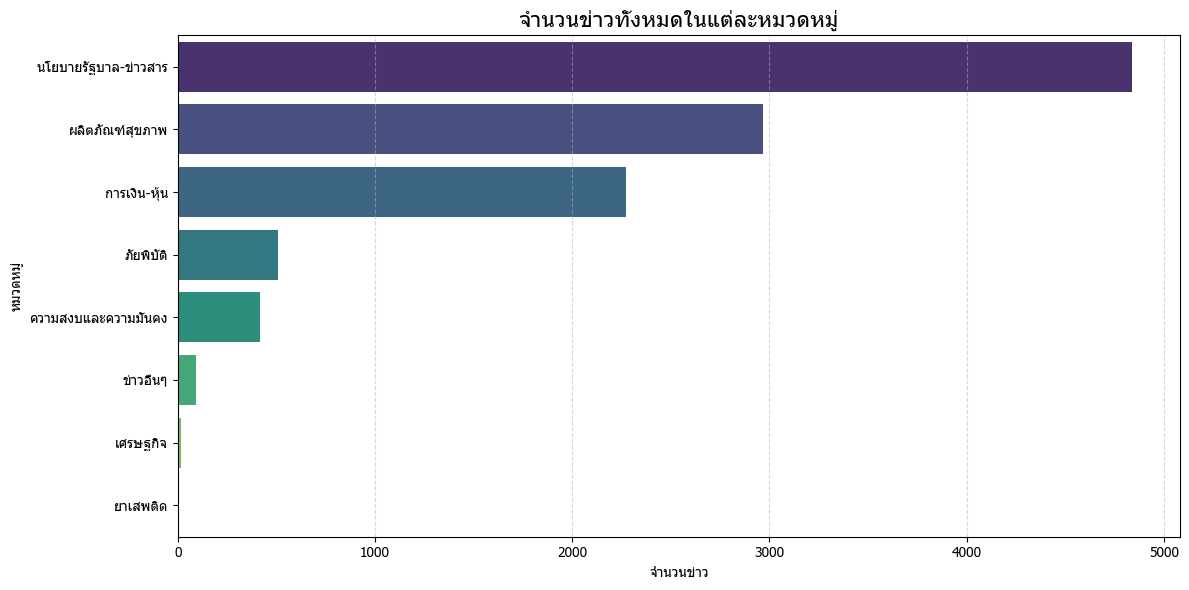

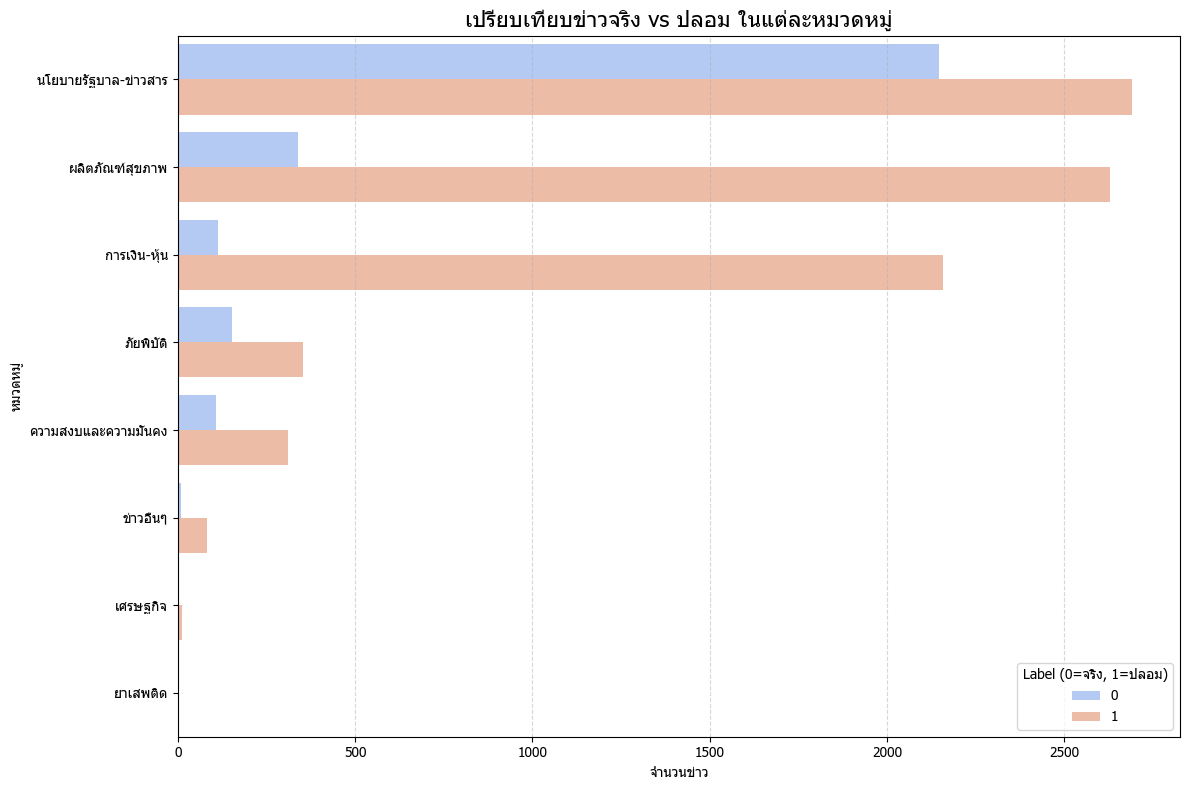

In [ ]:
# ════════════════════════════════════════════════════════════════
# PART 11 — Error Analysis: GCN Misclassified Samples
# ════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("PART 11 | Error Analysis — GCN Misclassified Samples")
print("="*70)
 
# GCN test indices ตาม test_mask
test_indices_gcn = np.where(data_gcn.test_mask.cpu().numpy())[0]
texts_gcn_test   = [texts_balanced[i] for i in test_indices_gcn]
 
misclassified = []
for i, (yt, yp) in enumerate(zip(y_true_gcn, y_pred_gcn)):
    if yt != yp:
        misclassified.append({
            'text':            texts_gcn_test[i],
            'true_label_text': id2label[yt],
            'pred_label_text': id2label[yp],
            'error_type':      ("False Positive (จริง→ปลอม)" if yp == 1
                                else "False Negative (ปลอม→จริง)"),
        })
 
print(f"ทายผิดทั้งหมด: {len(misclassified)} / {len(y_true_gcn)} (ตัวอย่าง 15 รายการแรก)")
for j, item in enumerate(misclassified[:15]):
    print(f"\n[{j+1}] ❌ {item['error_type']}")
    print(f"  ข่าว: {item['text']}")
    print(f"  จริง: {item['true_label_text']}  |  ทาย: {item['pred_label_text']}")
 

In [ ]:
# ════════════════════════════════════════════════════════════════
# PART 12 — Keyword Analysis (FP / FN)
# ════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("PART 12 | Keyword Analysis (FP / FN)")
print("="*70)
 
sw_base   = set(thai_stopwords())
sw_custom = {' ','\n','(',')','\"',"'",'!','?','-','"','"',':','/','ๆ',
             'ได้','ที่','ใน','การ','และ','เป็น','มี','ให้','ของ','จะ','ว่า'}
all_sw    = sw_base | sw_custom
 
def get_top_keywords(news_list, top_n=15):
    words = []
    for item in news_list:
        toks = word_tokenize(str(item['text']), engine='newmm', keep_whitespace=False)
        words.extend([w for w in toks if w not in all_sw and len(w) > 1])
    return Counter(words).most_common(top_n)
 
fp_news = [x for x in misclassified if 'Positive' in x['error_type']]
fn_news = [x for x in misclassified if 'Negative' in x['error_type']]
 
top_fp = get_top_keywords(fp_news)
top_fn = get_top_keywords(fn_news)
 
print(f"\nTop keywords — False Positive (จริงแต่ทายปลอม):")
for w, c in top_fp: print(f"  {w}: {c}")
print(f"\nTop keywords — False Negative (ปลอมแต่ทายจริง):")
for w, c in top_fn: print(f"  {w}: {c}")
 
if top_fp and top_fn:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    wfp, cfp = zip(*top_fp)
    wfn, cfn = zip(*top_fn)
    sns.barplot(x=list(cfp), y=list(wfp), ax=axes[0], palette='Reds_r')
    axes[0].set_title('คำในข่าวจริงที่โมเดลทายว่าปลอม (FP)', fontsize=13)
    axes[0].set_xlabel('ความถี่')
    sns.barplot(x=list(cfn), y=list(wfn), ax=axes[1], palette='Oranges_r')
    axes[1].set_title('คำในข่าวปลอมที่โมเดลทายว่าจริง (FN)', fontsize=13)
    axes[1].set_xlabel('ความถี่')
    plt.tight_layout()
    plt.savefig('img/graph_error_keywords.png', dpi=150)
    plt.show()
 


📊 Starting Data Analysis...

✅ 1. Creating Overall Distribution Graph...
หมวดหมู่ของข่าว
นโยบายรัฐบาล-ข่าวสาร    4838
ผลิตภัณฑ์สุขภาพ         2967
การเงิน-หุ้น            2271
ภัยพิบัติ                507
ความสงบและความมั่นคง     418
ข่าวอื่นๆ                 92
เศรษฐกิจ                  14
ยาเสพติด                   2
Name: count, dtype: int64


C:\Users\tt_pe\AppData\Local\Temp\ipykernel_24224\3876794720.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


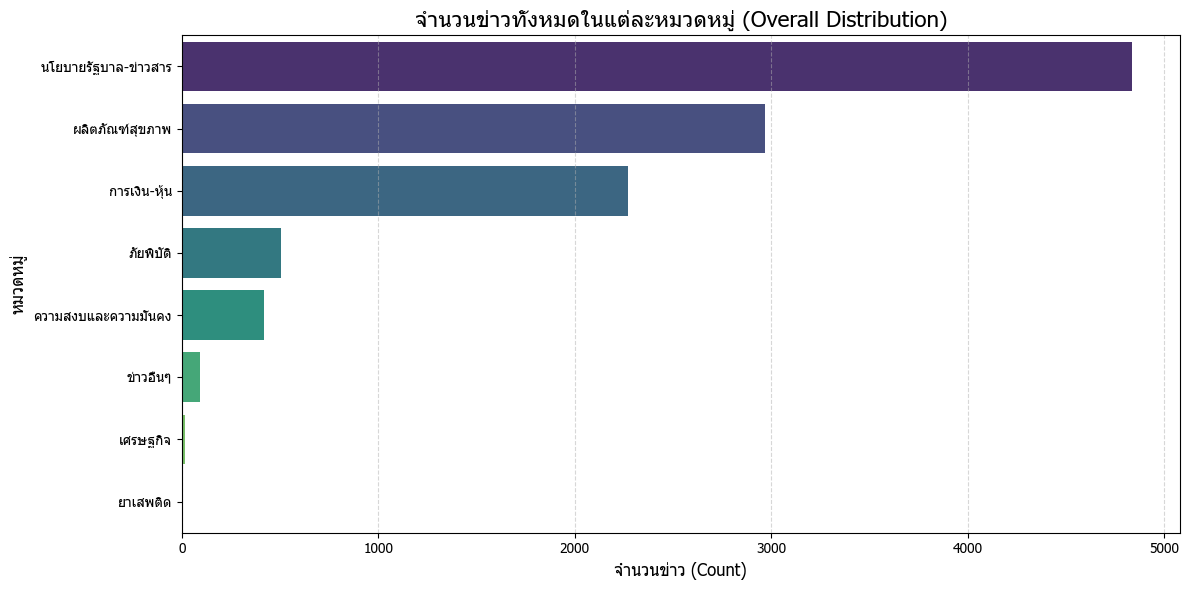


✅ 2. Creating Comparison Graph (Real vs Fake)...
label_binary          fake  true
หมวดหมู่ของข่าว                 
การเงิน-หุ้น          2158   111
ข่าวอื่นๆ               83     9
ความสงบและความมั่นคง   310    57
นโยบายรัฐบาล-ข่าวสาร  2692  2128
ผลิตภัณฑ์สุขภาพ       2629   335
ภัยพิบัติ              354   151
ยาเสพติด                 0     2
เศรษฐกิจ                11     3


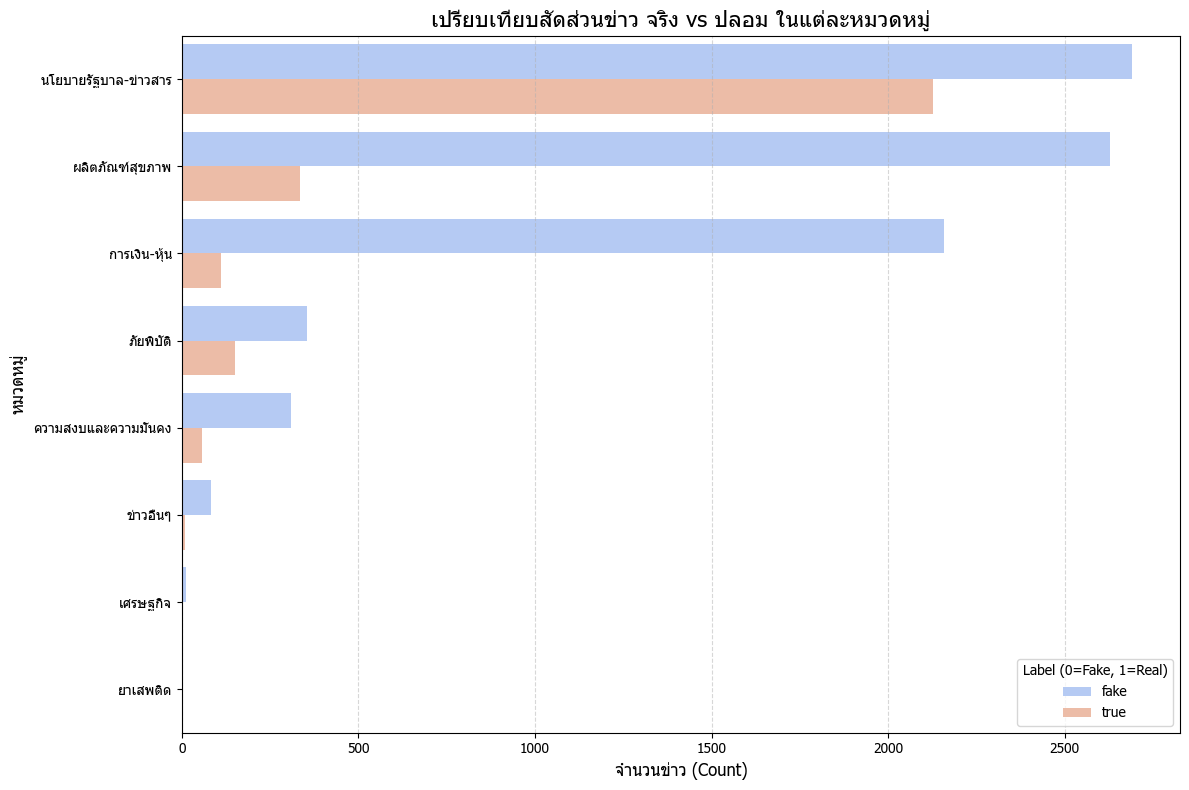


✅ Saved graphs: graph_category_total.png, graph_category_comparison.png


In [ ]:
# ════════════════════════════════════════════════════════════════
# PART 13 — Cross-Model Error Analysis
# ════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("PART 13 | Cross-Model Error Analysis  (ข่าวปราบเซียน)")
print("="*70)
 
df_cross = pd.DataFrame({
    'text':       test_texts,
    'true_label': y_test_base,
    'pred_gcn':   y_pred_gcn,
    'pred_rf':    y_pred_rf,
    'pred_xlm':   y_pred_xlm,
    'pred_tfidf': y_pred_tfidf,
})
df_cross['true_label_text'] = df_cross['true_label'].map(id2label)
 
for col, pred_col in [('gcn_wrong','pred_gcn'),('rf_wrong','pred_rf'),
                       ('xlm_wrong','pred_xlm'),('tfidf_wrong','pred_tfidf')]:
    df_cross[col] = df_cross['true_label'] != df_cross[pred_col]
 
df_cross['num_wrong'] = (df_cross[['gcn_wrong','rf_wrong','xlm_wrong','tfidf_wrong']]
                         .sum(axis=1))
 
all_wrong_df      = df_cross[df_cross['num_wrong'] == 4]
gcn_only_right_df = df_cross[(df_cross['num_wrong'] == 3) & (~df_cross['gcn_wrong'])]
 
print(f"Test set: {len(df_cross)} ข่าว")
print(f"  ทายผิดทั้ง 4 โมเดล (Hard Examples): {len(all_wrong_df)} ข่าว")
print(f"  GCN ทายถูก แต่อีก 3 โมเดลผิด     : {len(gcn_only_right_df)} ข่าว")
 
print("\n🚨 ตัวอย่าง Hard Examples (ทายผิดทั้ง 4 โมเดล):")
for _, row in all_wrong_df.head(10).iterrows():
    print(f"  ข่าว  : {row['text']}")
    print(f"  จริง  : {row['true_label_text']}")
    print("-" * 60)

In [ ]:
# ════════════════════════════════════════════════════════════════
# PART 14 — Per-Model Error Breakdown
# ════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("PART 14 | Per-Model Error Breakdown")
print("="*70)
 
models_eval = [
    ("1. WangchanBERT + kNN-GCN", y_pred_gcn),
    ("2. TF-IDF + LR",            y_pred_tfidf),
    ("3. WangchanBERT + RF",      y_pred_rf),
    ("4. XLM-RoBERTa + LR",      y_pred_xlm),
]
 
SHOW_N = 3
for mname, y_pred in models_eval:
    fp_list, fn_list = [], []
    for i, (yt, yp) in enumerate(zip(y_test_base, y_pred)):
        if yt != yp:
            rec = {'text': test_texts[i],
                   'true': id2label[yt], 'pred': id2label[yp]}
            (fp_list if yp == 1 else fn_list).append(rec)
 
    print(f"\n{'─'*60}")
    print(f"🤖 {mname}")
    print(f"   FP: {len(fp_list)} | FN: {len(fn_list)} | Total errors: {len(fp_list)+len(fn_list)}")
 
    print(f"  🔻 False Positive ({id2label[0]} → {id2label[1]}):")
    for j, r in enumerate(fp_list[:SHOW_N]):
        print(f"     [{j+1}] {r['text']}")
    if not fp_list: print("     (ไม่มี ✅)")
 
    print(f"  🔺 False Negative ({id2label[1]} → {id2label[0]}):")
    for j, r in enumerate(fn_list[:SHOW_N]):
        print(f"     [{j+1}] {r['text']}")
    if not fn_list: print("     (ไม่มี ✅)")
 
print("\n" + "="*70)
print("Pipeline complete.")
print("="*70)
 


SECTION 9: BUILD TEMPORAL GRAPH


C:\Users\tt_pe\AppData\Local\Temp\ipykernel_24224\1776523982.py:27: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  time_values = publish_dates.view('int64') // 10**9  # seconds


✅ Temporal Graph Built
   Nodes: 5744
   Edges: 57440
